In [115]:
import csv
import time
import struct
import threading
from dataclasses import dataclass
from pathlib import Path
from queue import Queue, Empty

import serial


In [116]:
@dataclass
class TestConfig:
    # Serial ports
    arduino_port: str = "COM9"  # change
    arduino_baud: int = 115200

    drone_port: str = "COM5"    # change
    drone_baud: int = 9600

    # Servo step profile (absolute times)
    # At time `profile_at_times_s[i]` (seconds from test start), command `profile_angles_deg[i]`.
    # Example: times=(0.0, 2.0, 5.0) angles=(0, 10, 0)
    profile_at_times_s: tuple[float, ...] = (0.0, 2.0, 5.0, 7.0)
    profile_angles_deg: tuple[int, ...] = (0, 10, -10, 0)

    # Which servo to sweep on the drone
    # One of: x_plus, x_minus, y_plus, y_minus
    servo_channel: str = "x_plus"

    # EDF is not used for this test (kept for protocol compatibility)
    edf_power_percent: int = 0

    # Base angles for the other servos (deg)
    base_x_plus_angle_deg: int = 0
    base_x_minus_angle_deg: int = 0
    base_y_plus_angle_deg: int = 0
    base_y_minus_angle_deg: int = 0

    # Drone-side encoding limit noted in the original Thrust notebook
    servo_min_angle_deg: int = -60
    servo_max_angle_deg: int = 60

    # Encoder scaling (for plotting / analysis)
    encoder_counts_per_rev: int = 1024  # change to match your encoder

    # Moving average over N raw samples
    moving_avg_window_samples: int = 10

    # Logging
    output_csv: str = "servo_encoder_log.csv"

    # Optional settling times
    pre_test_idle_s: float = 1.0
    post_test_idle_s: float = 1.0

cfg = TestConfig()
cfg


TestConfig(arduino_port='COM9', arduino_baud=115200, drone_port='COM5', drone_baud=9600, profile_at_times_s=(0.0, 2.0, 5.0, 7.0), profile_angles_deg=(0, 10, -10, 0), servo_channel='x_plus', edf_power_percent=0, base_x_plus_angle_deg=0, base_x_minus_angle_deg=0, base_y_plus_angle_deg=0, base_y_minus_angle_deg=0, servo_min_angle_deg=-60, servo_max_angle_deg=60, encoder_counts_per_rev=1024, moving_avg_window_samples=10, output_csv='servo_encoder_log.csv', pre_test_idle_s=1.0, post_test_idle_s=1.0)

In [117]:
# Drone UART framing helpers (copied from Thrust/pc_app/protocol.py)
SIG_SOF = 0xAA
PROTOCOL_VER = 0x01
FLAG_DATA = 0x05
ID_PC = 0x01
ID_DRONE = 0x20

OPT_CAL_PARAM = 0x60

def crc16_cal(data: bytes) -> int:
    crc = 0xFFFF
    for byte in data:
        crc ^= byte
        for _ in range(8):
            if crc & 0x0001:
                crc >>= 1
                crc ^= 0xA001
            else:
                crc >>= 1
    return crc & 0xFFFF

def build_frame(*, version: int, flags: int, src: int, dst: int, opcode: int, payload: bytes = b"") -> bytes:
    header = bytes([version, flags, src, dst, opcode, len(payload)])
    length = len(header) + len(payload) + 2  # header + payload + CRC16
    crc_input = bytes([length]) + header + payload
    crc = crc16_cal(crc_input)
    return bytes([SIG_SOF, length]) + header + payload + bytes([crc & 0xFF, (crc >> 8) & 0xFF])

def encode_servo_angle(angle_deg: int) -> int:
    # Drone expects stored_angle = real_angle + 90 (sent as int8)
    encoded = int(angle_deg) + 90
    if encoded < -128 or encoded > 127:
        raise ValueError(f"Encoded servo value out of int8 range: {encoded}")
    return encoded

def build_calib_frame(*, edf_pwr_percent: int, x_plus_angle_deg: int, x_minus_angle_deg: int, y_plus_angle_deg: int, y_minus_angle_deg: int) -> bytes:
    pwr = int(edf_pwr_percent)
    if not (0 <= pwr <= 100):
        raise ValueError("edf_pwr_percent must be in range 0..100")

    payload = struct.pack("<bbbbb", pwr, encode_servo_angle(x_plus_angle_deg), encode_servo_angle(x_minus_angle_deg), encode_servo_angle(y_plus_angle_deg), encode_servo_angle(y_minus_angle_deg))
    return build_frame(version=PROTOCOL_VER, flags=FLAG_DATA, src=ID_PC, dst=ID_DRONE, opcode=OPT_CAL_PARAM, payload=payload)

def frame_for_servo(cfg: TestConfig, angle_deg: int) -> bytes:
    ang = int(angle_deg)
    if ang < cfg.servo_min_angle_deg or ang > cfg.servo_max_angle_deg:
        raise ValueError(f"Angle {ang} out of range [{cfg.servo_min_angle_deg}, {cfg.servo_max_angle_deg}]")

    x_plus = cfg.base_x_plus_angle_deg
    x_minus = cfg.base_x_minus_angle_deg
    y_plus = cfg.base_y_plus_angle_deg
    y_minus = cfg.base_y_minus_angle_deg

    if cfg.servo_channel == "x_plus":
        x_plus = ang
    elif cfg.servo_channel == "x_minus":
        x_minus = ang
    elif cfg.servo_channel == "y_plus":
        y_plus = ang
    elif cfg.servo_channel == "y_minus":
        y_minus = ang
    else:
        raise ValueError(f"Invalid servo_channel: {cfg.servo_channel!r}")

    return build_calib_frame(
        edf_pwr_percent=cfg.edf_power_percent,
        x_plus_angle_deg=x_plus,
        x_minus_angle_deg=x_minus,
        y_plus_angle_deg=y_plus,
        y_minus_angle_deg=y_minus,
    )


In [118]:
@dataclass
class SensorSample:
    pc_time_s: float
    arduino_time_us: int
    enc_count: int

class ArduinoReader(threading.Thread):
    def __init__(self, ser: serial.Serial, out_queue: Queue):
        super().__init__(daemon=True)
        self.ser = ser
        self.out_queue = out_queue
        self._stop = threading.Event()

    def stop(self):
        self._stop.set()

    def run(self):
        while not self._stop.is_set():
            try:
                line = self.ser.readline().decode("utf-8", errors="ignore").strip()
                if not line or line.startswith("#"):
                    continue

                parts = line.split(",")
                if len(parts) < 2:
                    continue

                arduino_time_us = int(parts[0])
                enc_count = int(parts[1])

                self.out_queue.put(
                    SensorSample(
                        pc_time_s=time.time(),
                        arduino_time_us=arduino_time_us,
                        enc_count=enc_count,
                    )
                )

            except Exception:
                # keep running even if one line is corrupted
                continue


In [119]:
from collections import deque


def build_profile_events(cfg: TestConfig) -> list[tuple[float, int]]:
    times = list(cfg.profile_at_times_s)
    angles = list(cfg.profile_angles_deg)

    if len(times) != len(angles):
        raise ValueError("profile_at_times_s and profile_angles_deg must have the same length")
    if len(times) == 0:
        raise ValueError("profile_at_times_s/profile_angles_deg must not be empty")

    events: list[tuple[float, int]] = []
    last_t = None
    for i, (t, ang) in enumerate(zip(times, angles)):
        t_f = float(t)
        ang_i = int(ang)
        if t_f < 0:
            raise ValueError(f"profile_at_times_s[{i}] must be >= 0")
        if last_t is not None and t_f < last_t:
            raise ValueError("profile_at_times_s must be non-decreasing")
        events.append((t_f, ang_i))
        last_t = t_f

    return events


def run_servo_test(cfg: TestConfig):
    events = build_profile_events(cfg)
    output_path = Path(cfg.output_csv)

    sensor_queue = Queue()
    rows = []

    enc_window = deque(maxlen=cfg.moving_avg_window_samples)

    print("Opening serial ports...")

    arduino_ser = serial.Serial(cfg.arduino_port, cfg.arduino_baud, timeout=0.2, dsrdtr=False, rtscts=False)

    # Ensure boards that do `while (!Serial)` can start (Serial Monitor asserts DTR)
    try:
        arduino_ser.dtr = False
        arduino_ser.rts = False
        time.sleep(0.05)
        arduino_ser.dtr = True
    except Exception:
        pass

    drone_ser = serial.Serial(cfg.drone_port, cfg.drone_baud, timeout=0.2, dsrdtr=False, rtscts=False)

    time.sleep(2)  # allow ports to stabilize

    reader = None

    current_angle = events[0][1]
    current_step_index = -1
    current_direction = "idle"
    last_step_change_pc_s = time.time()
    transition_flag = 0
    last_frame_hex = ""

    def drain_queue():
        nonlocal transition_flag
        while True:
            try:
                sample = sensor_queue.get_nowait()
            except Empty:
                break

            raw_enc = sample.enc_count
            enc_window.append(raw_enc)
            avg_enc = sum(enc_window) / len(enc_window)

            meas_deg = (avg_enc * 360.0) / float(cfg.encoder_counts_per_rev) if cfg.encoder_counts_per_rev else float('nan')

            row = {
                'pc_time_s': sample.pc_time_s,
                'arduino_time_us': sample.arduino_time_us,
                'step_index': current_step_index,
                'step_direction': current_direction,
                'servo_channel': cfg.servo_channel,
                'commanded_angle_deg': current_angle,
                'encoder_count_raw': raw_enc,
                'encoder_count_moving_avg': avg_enc,
                'encoder_angle_deg': meas_deg,
                'encoder_counts_per_rev': cfg.encoder_counts_per_rev,
                'moving_avg_window_samples': cfg.moving_avg_window_samples,
                'transition_flag': transition_flag,
                'time_since_step_s': sample.pc_time_s - last_step_change_pc_s,
                'sent_frame_hex': last_frame_hex,
            }

            rows.append(row)
            transition_flag = 0

    def wait_until(t_target_s: float, t0_s: float) -> None:
        while True:
            drain_queue()
            now_rel = time.time() - t0_s
            if now_rel >= t_target_s:
                return
            time.sleep(0.002)

    try:
        # ---------------------------
        # ZERO BEFORE TEST (same command as Thrust: 'T')
        # ---------------------------
        print("Sending TARE/ZERO command to Arduino...")
        arduino_ser.reset_input_buffer()
        arduino_ser.write(b'T')
        arduino_ser.flush()

        tare_deadline = time.time() + 15.0
        while True:
            if time.time() > tare_deadline:
                raise TimeoutError('Timed out waiting for TARE_DONE from Arduino')

            line = arduino_ser.readline().decode(errors='ignore').strip()
            if line:
                print('Arduino:', line)
            if 'TARE_DONE' in line:
                break

        print('Zero completed')
        print('Waiting for system to stabilize...')
        time.sleep(cfg.pre_test_idle_s)

        reader = ArduinoReader(arduino_ser, sensor_queue)
        reader.start()

        # ---------------------------
        # START SERVO PROFILE (absolute timing)
        # ---------------------------
        print('Starting servo profile (absolute times)')
        print('Events (t_s, angle_deg):', events)

        t0 = time.time()
        prev_ang = None
        for step_idx, (t_s, ang) in enumerate(events):
            wait_until(t_s, t0)

            if prev_ang is None:
                direction = 'hold'
            else:
                if ang > prev_ang:
                    direction = 'up'
                elif ang < prev_ang:
                    direction = 'down'
                else:
                    direction = 'hold'

            frame = frame_for_servo(cfg, ang)
            drone_ser.write(frame)
            drone_ser.flush()

            current_angle = ang
            current_step_index = step_idx
            current_direction = direction
            last_step_change_pc_s = time.time()
            transition_flag = 1
            last_frame_hex = frame.hex(' ')

            now_rel = time.time() - t0
            print(f"Step {step_idx:03d} | t={t_s:7.3f}s (now={now_rel:7.3f}s) | direction={direction:>4s} | {cfg.servo_channel}={ang:4d} deg | frame={last_frame_hex}")
            prev_ang = ang

        print('Waiting after final step...')
        time.sleep(cfg.post_test_idle_s)
        drain_queue()

    finally:
        if reader is not None:
            reader.stop()
        time.sleep(0.2)
        drain_queue()

        try:
            arduino_ser.close()
        except Exception:
            pass

        try:
            drone_ser.close()
        except Exception:
            pass

    fieldnames = [
        'pc_time_s',
        'arduino_time_us',
        'step_index',
        'step_direction',
        'servo_channel',
        'commanded_angle_deg',
        'encoder_count_raw',
        'encoder_count_moving_avg',
        'encoder_angle_deg',
        'encoder_counts_per_rev',
        'moving_avg_window_samples',
        'transition_flag',
        'time_since_step_s',
        'sent_frame_hex',
    ]

    output_path.parent.mkdir(parents=True, exist_ok=True)
    with open(output_path, 'w', newline='') as f:
        writer = csv.DictWriter(f, fieldnames=fieldnames)
        writer.writeheader()
        writer.writerows(rows)

    print(f"Saved {len(rows)} rows to {output_path}")
    return rows


In [120]:
cfg = TestConfig(
    arduino_port="COM9",     # Arduino port
    drone_port="COM5",       # drone/UART port
    drone_baud=9600,
    arduino_baud=115200,
    servo_channel="y_plus",
    # Absolute timing: at t=0 -> 0deg, t=1.5 -> 10deg, t=3.5 -> -10deg, ...
    profile_at_times_s=(0.0, 1, 3, 5, 7, 9, 11, 13, 15, 17),
    profile_angles_deg=(0, 10, -10, 15, -15, 30, -30, -5, 5, 0),
    moving_avg_window_samples=5,
    encoder_counts_per_rev=1000,
    output_csv="Meritve/servo_encoder_log.csv",
)

rows = run_servo_test(cfg)


Opening serial ports...
Sending TARE/ZERO command to Arduino...
Arduino: # TARE_DONE
Zero completed
Waiting for system to stabilize...
Starting servo profile (absolute times)
Events (t_s, angle_deg): [(0.0, 0), (1.0, 10), (3.0, -10), (5.0, 15), (7.0, -15), (9.0, 30), (11.0, -30), (13.0, -5), (15.0, 5), (17.0, 0)]
Step 000 | t=  0.000s (now=  0.001s) | direction=hold | y_plus=   0 deg | frame=aa 0d 01 05 01 20 60 05 00 5a 5a 5a 5a 7a b6
Step 001 | t=  1.000s (now=  1.003s) | direction=  up | y_plus=  10 deg | frame=aa 0d 01 05 01 20 60 05 00 5a 5a 64 5a 6a d6
Step 002 | t=  3.000s (now=  3.003s) | direction=down | y_plus= -10 deg | frame=aa 0d 01 05 01 20 60 05 00 5a 5a 50 5a 7c 16
Step 003 | t=  5.000s (now=  5.001s) | direction=  up | y_plus=  15 deg | frame=aa 0d 01 05 01 20 60 05 00 5a 5a 69 5a 6e 46
Step 004 | t=  7.000s (now=  7.001s) | direction=down | y_plus= -15 deg | frame=aa 0d 01 05 01 20 60 05 00 5a 5a 4b 5a 76 e6
Step 005 | t=  9.000s (now=  9.002s) | direction=  up | y_pl

In [121]:
import pandas as pd

csv_file = "Meritve/servo_encoder_log.csv"
df = pd.read_csv(csv_file)
df['pc_time_s_rel'] = df['pc_time_s'] - df['pc_time_s'].iloc[0]
df.head()


,pc_time_s,arduino_time_us,step_index,step_direction,servo_channel,commanded_angle_deg,encoder_count_raw,encoder_count_moving_avg,encoder_angle_deg,encoder_counts_per_rev,moving_avg_window_samples,transition_flag,time_since_step_s,sent_frame_hex,pc_time_s_rel
0,1.776965e+09,1391703301,0,hold,y_plus,0,0,0.0,0.0,1000,5,1,0.000456,aa 0d 01 05 01 20 60 05 00 5a 5a 5a 5a 7a b6,0.000000
1,1.776965e+09,1391723306,0,hold,y_plus,0,0,0.0,0.0,1000,5,0,0.000575,aa 0d 01 05 01 20 60 05 00 5a 5a 5a 5a 7a b6,0.000119
2,1.776965e+09,1391743306,0,hold,y_plus,0,0,0.0,0.0,1000,5,0,0.000685,aa 0d 01 05 01 20 60 05 00 5a 5a 5a 5a 7a b6,0.000229
3,1.776965e+09,1391763308,0,hold,y_plus,0,0,0.0,0.0,1000,5,0,0.000790,aa 0d 01 05 01 20 60 05 00 5a 5a 5a 5a 7a b6,0.000334
4,1.776965e+09,1391783309,0,hold,y_plus,0,0,0.0,0.0,1000,5,0,0.000895,aa 0d 01 05 01 20 60 05 00 5a 5a 5a 5a 7a b6,0.000438


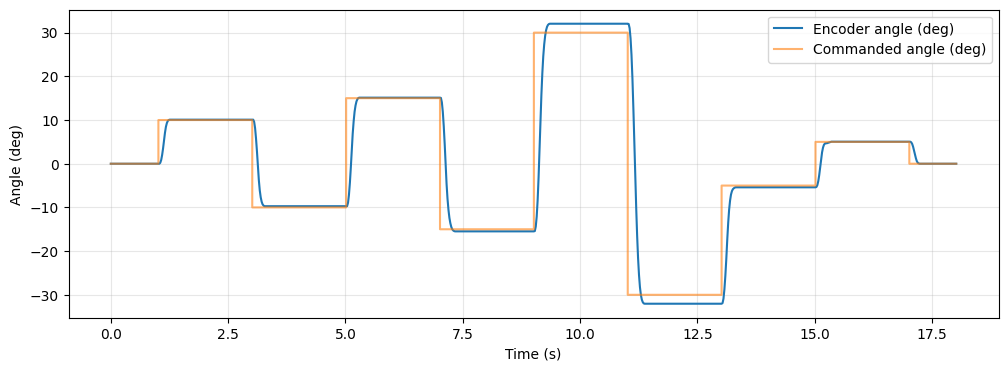

In [122]:
import matplotlib.pyplot as plt

fig, ax = plt.subplots(figsize=(12, 4))
ax.plot(df['pc_time_s_rel'], df['encoder_angle_deg'], label='Encoder angle (deg)')
ax.step(df['pc_time_s_rel'], df['commanded_angle_deg'], where='post', label='Commanded angle (deg)', alpha=0.6)
ax.set_xlabel('Time (s)')
ax.set_ylabel('Angle (deg)')
ax.grid(True, alpha=0.3)
ax.legend()
plt.show()


In [123]:
# Quick step summary: average the last N samples of each step
tail_n = 20
tail = df.groupby('step_index', group_keys=False).tail(tail_n)
step_summary = (
    tail.groupby('step_index')
    .agg(
        servo_channel=('servo_channel', 'last'),
        commanded_angle_deg=('commanded_angle_deg', 'last'),
        measured_angle_deg=('encoder_angle_deg', 'mean'),
        measured_angle_std=('encoder_angle_deg', 'std'),
        n=('encoder_angle_deg', 'size'),
    )
)
step_summary['error_deg'] = step_summary['measured_angle_deg'] - step_summary['commanded_angle_deg']
step_summary


,servo_channel,commanded_angle_deg,measured_angle_deg,measured_angle_std,n,error_deg
step_index,,,,,,
0,y_plus,0,0.00,0.0,20,0.00
1,y_plus,10,10.08,0.0,20,0.08
2,y_plus,-10,-9.72,0.0,20,0.28
3,y_plus,15,15.12,0.0,20,0.12
4,y_plus,-15,-15.48,0.0,20,-0.48
5,y_plus,30,32.04,0.0,20,2.04
6,y_plus,-30,-32.04,0.0,20,-2.04
7,y_plus,-5,-5.40,0.0,20,-0.40
8,y_plus,5,5.04,0.0,20,0.04
